In [ ]:
### --- Test reading of campbell scientific datalogger files --- ### 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to Campbell CR6 .csv files
file_path = "/Users/xduplm/Google Drive/My Drive/projects/waveglider-campbell-data/wg-test-data/"

### Gill R3-50 Anemometer

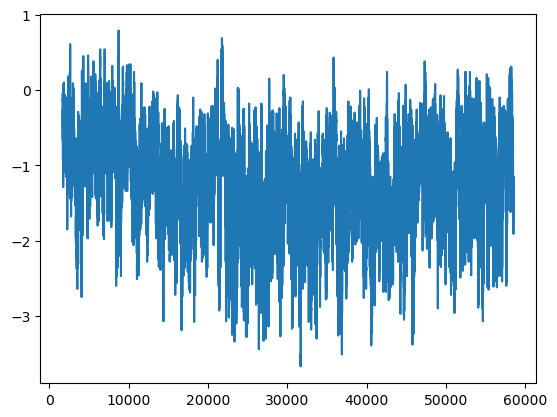

In [108]:
file = os.path.join(file_path, "PLD1_Gill94.csv")
# Parse the .csv file using pandas
df = pd.read_csv(file, skiprows=1)
df = df.iloc[2:]

# Convert Ux_gill to numeric, coerce errors
df['Ux_gill'] = pd.to_numeric(df['Ux_gill'], errors='coerce')
df['Uy_gill'] = pd.to_numeric(df['Uy_gill'], errors='coerce')
df['Uz_gill'] = pd.to_numeric(df['Uz_gill'], errors='coerce')

# Plot
df['Ux_gill'].plot()
plt.show()

In [109]:
df.head()

,TIMESTAMP,staA,staD,Ux_gill,Uy_gill,Uz_gill,Speed_sound,Checksum_gill
2,2026-05-21 08:12:05.500,NAN,NAN,NaN,NaN,NaN,NAN,0
3,2026-05-21 08:12:05.550,NAN,NAN,NaN,NaN,NaN,NAN,0
4,2026-05-21 08:12:05.600,NAN,NAN,NaN,NaN,NaN,NAN,0
5,2026-05-21 08:12:05.650,NAN,NAN,NaN,NaN,NaN,NAN,0
6,2026-05-21 08:12:05.700,NAN,NAN,NaN,NaN,NaN,NAN,0


In [111]:
# Calculate frequency of data in the Gill dataframe

time_col = None
for col in ["TIMESTAMP", "Timestamp", "DateTime"]:
    if col in df.columns:
        time_col = col
        break

if time_col:
    # Convert to datetime if not already
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    # Calculate time differences in seconds
    time_diffs = df[time_col].sort_values().diff().dt.total_seconds().dropna()
    if not time_diffs.empty:
        freq = 1 / time_diffs.mode()[0]  # Most common interval
        print(f"Estimated data frequency: {freq:.2f} Hz")
    else:
        print("Not enough data to calculate frequency.")
else:
    print("No timestamp column found to calculate frequency.")

Estimated data frequency: 20.00 Hz


### RBR Legato

In [112]:
file = os.path.join(file_path, "PLD1_RBR94.csv")
# Parse the .csv file using pandas
df = pd.read_csv(file, skiprows=1)
df = df.iloc[2:]

In [113]:
df

,TIMESTAMP,RBR_Conductivity,RBR_Temp,RBR_Pressure,RBR_SeaPressure,RBR_Depth,RBR_Salinity,RBR_MeasurementCount,RBR_Temp_Correction,CODA_Temp,CODA_Oxygen,CODA_Phase,Cyclops_Chlorophyll
2,2026-05-21 08:11:57.000,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN
3,2026-05-21 08:11:58.000,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN
4,2026-05-21 08:11:59.000,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN
5,2026-05-21 08:12:00.000,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN
6,2026-05-21 08:12:01.000,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN,NAN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934,2026-05-21 12:59:56.000,0.003,16.86,10.14,0.007,0.007,0.009,1,16.8,17.17,257.7,33.57,18.53
2935,2026-05-21 12:59:57.000,0.004,16.85,10.14,0.012,0.012,0.01,1,16.81,17.17,257.6,33.57,18.52
2936,2026-05-21 12:59:58.000,0.005,16.85,10.14,0.012,0.012,0.01,1,16.79,17.17,257.8,33.57,18.52
2937,2026-05-21 12:59:59.000,0.005,16.85,10.14,0.008,0.008,0.01,1,16.8,17.17,257.2,33.59,18.53


### SPN Radiometer

In [126]:
file = os.path.join(file_path, "PLD1_SPN196.csv")
# Parse the .csv file using pandas
df = pd.read_csv(file, skiprows=1)
df = df.iloc[2:]

In [127]:
df['SPN1_Raw_Diffuse'] = pd.to_numeric(df['SPN1_Raw_Diffuse'], errors='coerce')
df['SPN1_Raw_Total'] = pd.to_numeric(df['SPN1_Raw_Total'], errors='coerce')

In [128]:
df.head()

,TIMESTAMP,SPN1_Raw_Diffuse,SPN1_Raw_Total
2,2026-05-21 14:00:30.000,-910,99.7
3,2026-05-21 14:01:00.000,-886,97.3
4,2026-05-21 14:01:30.000,-910,96.0
5,2026-05-21 14:02:00.000,-886,96.0
6,2026-05-21 14:02:30.000,-910,96.0


<Axes: >

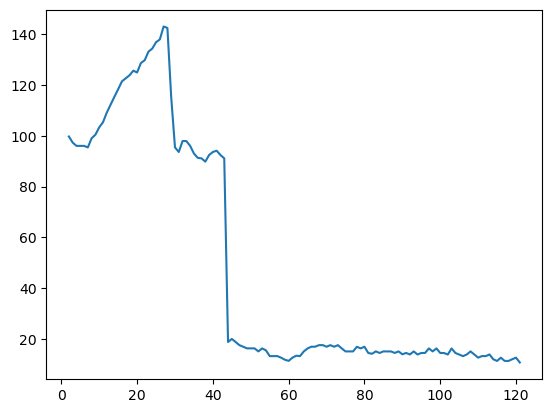

In [129]:
df['SPN1_Raw_Total'].plot()

### CGR4 Kipp and Zonon Pyrgeometer

In [2]:
file = os.path.join(file_path, "PLD1_CGR494.csv")
# Parse the .csv file using pandas
df = pd.read_csv(file, skiprows=1)
df = df.iloc[2:, :]

# Convert TIMESTAMP to datetime and set as index
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")

In [3]:
df.head()

,TIMESTAMP,CGR4_Raw_mVolt,CGR4_Raw_Vtherm
2,2026-05-21 08:00:30,-73.41,1
3,2026-05-21 08:01:00,-83.2,1
4,2026-05-21 08:01:30,-75,1
5,2026-05-21 08:02:00,-72,1
6,2026-05-21 08:02:30,-109.9,1


#### Converting CGR4 raw voltages to downward longwave radiation

The CGR4 pyrgeometer measures a thermopile voltage that responds to the difference between the incoming longwave irradiance and the thermal emission of the instrument body. The calibration certificates for our two CGR4 instruments provide sensor-specific sensitivities $S$ in µV per W m-2 (serial 300054: 13.25 µV/(W m-2); serial 300055: 7.77 µV/(W m-2)). -->

Following the manufacturer’s pyrgeometer algorithm, the downward longwave
irradiance $L_\downarrow$ is computed as

$$
L_\downarrow = \frac{U_\text{emf}}{S} + \sigma T_\text{body}^4
$$

where:

- $U_\text{emf}$ is the thermopile signal in volts, obtained from the
  `CGR4_Raw_mVolt` column by converting mV to V.
- $S$ is the instrument sensitivity in V per W m$^{-2}$, computed from the
  certificate value by multiplying by $10^{-6}$.
- $\sigma$ is the Stefan–Boltzmann constant $5.67\times10^{-8}$
  W m$^{-2}$ K$^{-4}$.
- $T_\text{body}$ is the pyrgeometer body temperature in kelvin, derived
  from the body-temperature thermistor (`CGR4_Raw_Vtherm`) and the logger
  wiring; in the code we assume a `T_body_C` column in °C and convert to K.

In Python, we:

1. Read the TOA5-style CSV exported from `camp2ascii`.
2. Convert the thermopile output from mV to V.
3. Apply the sensitivity $S$ from the calibration certificate to obtain
   the radiative term $U_\text{emf}/S$.
4. Convert body temperature from °C to K and evaluate $\sigma T^4$.
5. Sum both terms to get $L_\downarrow$ in W m$^{-2}$ and store it as a new
   column `L_down_Wm2`.

The only experiment-specific part of the calculation is the conversion from
`CGR4_Raw_Vtherm` to body temperature. Once the thermistor wiring and
coefficients used in the CR6 program are known, that relation can be coded
as a function and used to populate the `T_body_C` column before applying the
longwave calculation.

In [46]:
import pandas as pd
import numpy as np

SIGMA = 5.670374419e-8  # Stefan–Boltzmann constant [W m^-2 K^-4]

# --- 1. Start from your existing df as shown in the screenshot ---

# Convert numeric columns from strings to floats
df["CGR4_Raw_mVolt"] = pd.to_numeric(df["CGR4_Raw_mVolt"], errors="coerce")
df["CGR4_Raw_Vtherm"] = pd.to_numeric(df["CGR4_Raw_Vtherm"], errors="coerce")

# Parse timestamp if useful
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

# --- 2. Placeholder: convert thermistor voltage to body temperature in °C ---
# TODO: replace this with real conversion based on CR6 wiring and thermistor coefficients
def vtherm_to_T_body_C(v):
    # For now just return a constant; replace with proper Steinhart–Hart or bridge equation.
    return 20.0 + 0.0 * v

df["T_body_C"] = vtherm_to_T_body_C(df["CGR4_Raw_Vtherm"])

# --- 3. CGR4 sensitivities from calibration certificates ---
S_300054 = 13.25e-6  # V / (W m^-2)  [file:58]
S_300055 = 7.77e-6   # V / (W m^-2)  [file:59]

# Choose the right one for this dataframe:
S = S_300054  # or S_300055 depending on which instrument this file belongs to

# --- 4. Compute downward longwave irradiance ---
# Convert thermopile mV -> V
U_therm_V = df["CGR4_Raw_mVolt"] * 1e-3

# Thermopile term: U_emf / S
L_therm = U_therm_V / S

# Body temperature term: σ T^4
T_body_K = df["T_body_C"] + 273.15
L_body = SIGMA * np.power(T_body_K, 4)

# Total downward longwave
df["L_down_Wm2"] = L_therm + L_body

# Inspect result
print(df[["TIMESTAMP", "CGR4_Raw_mVolt", "CGR4_Raw_Vtherm", "T_body_C", "L_down_Wm2"]].head())

            TIMESTAMP  CGR4_Raw_mVolt  CGR4_Raw_Vtherm  T_body_C   L_down_Wm2
3 2026-05-21 08:00:30          -73.41              1.0      20.0 -5121.611438
4 2026-05-21 08:01:00          -83.20              1.0      20.0 -5860.479363
5 2026-05-21 08:01:30          -75.00              1.0      20.0 -5241.611438
6 2026-05-21 08:02:00          -72.00              1.0      20.0 -5015.196344
7 2026-05-21 08:02:30         -109.90              1.0      20.0 -7875.573703


/var/folders/sd/cjy_dg9n7c1dk_jqyd4dnzbw0000gn/T/ipykernel_15412/3650742634.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CGR4_Raw_mVolt"] = pd.to_numeric(df["CGR4_Raw_mVolt"], errors="coerce")
/var/folders/sd/cjy_dg9n7c1dk_jqyd4dnzbw0000gn/T/ipykernel_15412/3650742634.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CGR4_Raw_Vtherm"] = pd.to_numeric(df["CGR4_Raw_Vtherm"], errors="coerce")
/var/folders/sd/cjy_dg9n7c1dk_jqyd4dnzbw0000gn/T/ipykernel_15412/3650742634.py:13: SettingWithCopyWar